In [1]:
%matplotlib inline

In [2]:
from src.utils.gantt_utils import (
    load_project_sheet,
    load_template_sheet,
    build_project_schedule_forward,
    build_project_schedule_backward,
    build_master_schedule,
    plot_gantt,
    plot_gantt_weekly,
    build_daily_role_demand,
    plot_daily_role_demand
)

In [3]:
file_path = "data/project_tasks.xlsx"

projects = load_project_sheet(file_path)
projects

,project_name,template_name,deadline,startline,buffer_days
0,Jembatan Medan,CES,NaT,2026-07-01,0
1,Jembatan Medan,SD,NaT,2026-07-01,0
2,Jembatan Medan,FT,NaT,2026-07-01,0
3,Jembatan Jakarta,CES,2026-08-01,NaT,0
4,Jembatan Jakarta,SD,NaT,2026-06-26,0
5,Jembatan Jakarta,FT,NaT,2026-06-26,0


In [4]:
ces = load_template_sheet(file_path, "CES")
ces

,task_id,dependencies,task_group,task_description,duration_days,role
0,1,,Section & Material Input,Defining section and material properties,2,CES Engineer
1,2,1.0,Stucture Geometry,Construct structural frame,3,CES Engineer
2,3,2.0,Boundary Condition,Define supports and links,1,CES Engineer
3,4,1.0,SSI Parameter,Define supports and links,3,Supporting Engineer
4,5,3.0,Tendon Input,Input tendon profile,3,CES Engineer
5,6,5.0,Bridge Loading,"Define bridge loads, construction and service ...",4,CES Engineer
6,7,6.0,Construction Sequence Model,Build staged construction,3,CES Engineer
7,8,7.0,Seismic Construction Analysis,Analysis for seismic construction,3,CES Engineer
8,9,8.0,Construction Stage Analysis,Sequential stress check,5,CES Engineer
9,10,9.0,SLS Analysis,Analysis for service coondition,5,CES Engineer


In [5]:
projects = load_project_sheet(file_path)

# build the project schedule forward from the startline:
medan_ces = build_project_schedule_forward(file_path, projects.iloc[0])

#if you want to build the schedule backward from the deadline, use:
# medan_ces = build_project_schedule_backward(file_path, projects.iloc[0])

medan_ces[["task_id", "task_group", "dependencies", "role", "start_date", "end_date"]]

,task_id,task_group,dependencies,role,start_date,end_date
0,1,Section & Material Input,,CES Engineer,2026-07-01,2026-07-02
1,2,Stucture Geometry,1.0,CES Engineer,2026-07-03,2026-07-05
2,4,SSI Parameter,1.0,Supporting Engineer,2026-07-03,2026-07-05
3,3,Boundary Condition,2.0,CES Engineer,2026-07-06,2026-07-06
4,12,Jacking force,4.0,Supporting Engineer,2026-07-06,2026-07-12
5,5,Tendon Input,3.0,CES Engineer,2026-07-07,2026-07-09
6,6,Bridge Loading,5.0,CES Engineer,2026-07-10,2026-07-13
7,7,Construction Sequence Model,6.0,CES Engineer,2026-07-14,2026-07-16
8,8,Seismic Construction Analysis,7.0,CES Engineer,2026-07-17,2026-07-19
9,9,Construction Stage Analysis,8.0,CES Engineer,2026-07-20,2026-07-24


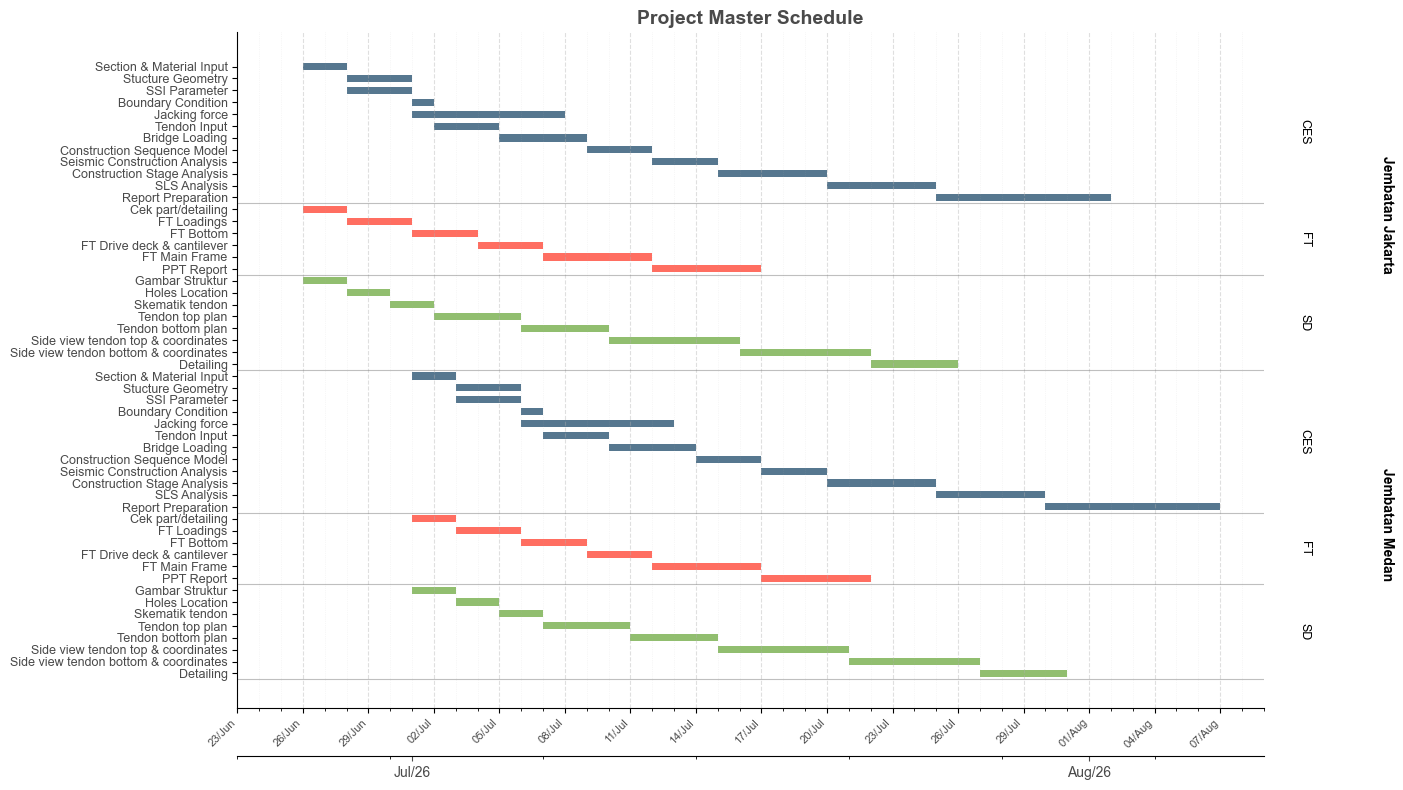

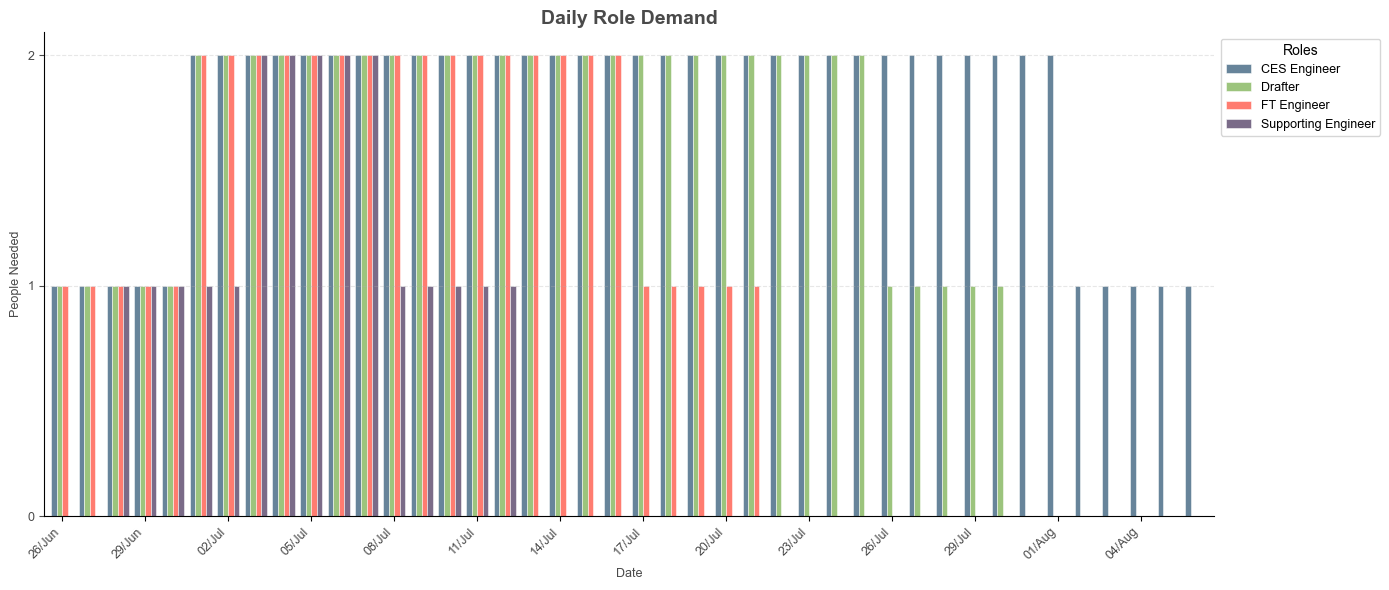

In [6]:
master_schedule = build_master_schedule(file_path)
plot_gantt(master_schedule)
# plot_gantt_weekly(master_schedule)
plot_daily_role_demand(master_schedule)

In [7]:

weekly_demand = build_daily_role_demand(master_schedule)
import pandas as pd

# Set options to show everything
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    print(weekly_demand)

          date                 role  people_needed
0   2026-06-26         CES Engineer              1
1   2026-06-26              Drafter              1
2   2026-06-26          FT Engineer              1
3   2026-06-26  Supporting Engineer              0
4   2026-06-27         CES Engineer              1
5   2026-06-27              Drafter              1
6   2026-06-27          FT Engineer              1
7   2026-06-27  Supporting Engineer              0
8   2026-06-28         CES Engineer              1
9   2026-06-28              Drafter              1
10  2026-06-28          FT Engineer              1
11  2026-06-28  Supporting Engineer              1
12  2026-06-29         CES Engineer              1
13  2026-06-29              Drafter              1
14  2026-06-29          FT Engineer              1
15  2026-06-29  Supporting Engineer              1
16  2026-06-30         CES Engineer              1
17  2026-06-30              Drafter              1
18  2026-06-30          FT Engi